In [2]:
import numpy as np
import scipy as sp
from math import e
import matplotlib.pyplot as plt

Zadanie 1

In [3]:
proby = sp.stats.lognorm.rvs(s=1,size=(100000, 1000))
srednie = np.mean(proby,axis=0)
print(len(srednie))

1000


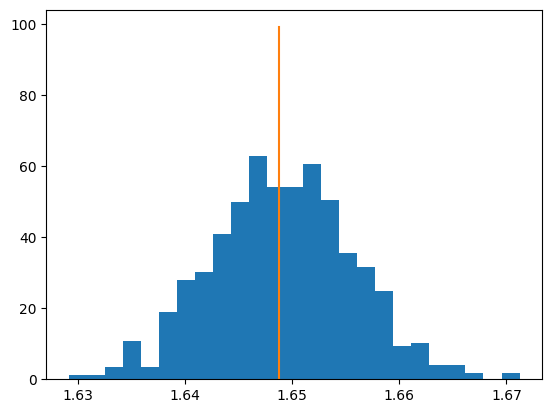

In [4]:
plt.hist(srednie, density=True,bins="auto")
plt.plot([e**0.5]*100, np.arange(0,100,1))
plt.show()

In [5]:
print(f"srednia estymatora: {np.mean(srednie)}")
print(f"wariancja estymatora: {np.var(srednie)}")
print(f"wartosc teoretyczna średniej: {e**0.5}")

srednia estymatora: 1.6490973760929233
wariancja estymatora: 4.388257439971446e-05
wartosc teoretyczna średniej: 1.6487212707001282


Zadanie 2

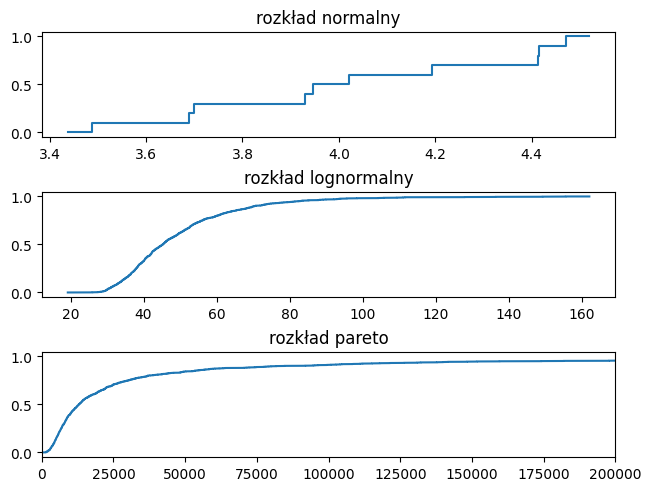

In [6]:
u1 = np.max(sp.stats.norm.rvs(size=(10,10000)), axis=1)
u2 = np.max(sp.stats.lognorm.rvs(s=1,size=(1000, 10000)), axis=1)
u3 = np.max(sp.stats.pareto.rvs(b=1,size=(1000, 10000)), axis=1)

fig, ax = plt.subplots(nrows=3, constrained_layout=True)
sp.stats.ecdf(u1).cdf.plot(ax[0])
ax[0].set_title("rozkład normalny")
sp.stats.ecdf(u2).cdf.plot(ax[1])
ax[1].set_title("rozkład lognormalny")
sp.stats.ecdf(u3).cdf.plot(ax[2])
ax[2].set_title("rozkład pareto")
ax[2].set_xlim(0,200000)
plt.show()

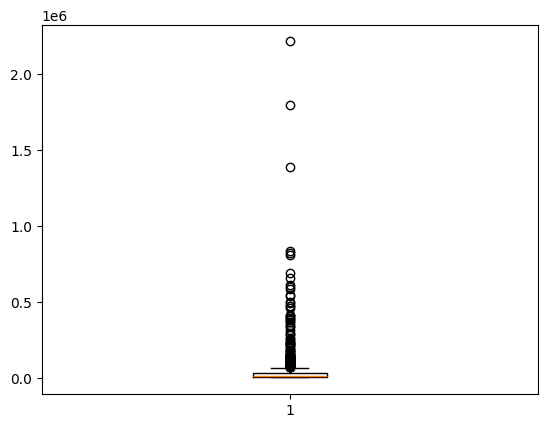

In [7]:
plt.boxplot(u3)
plt.show()

Zadanie 6

In [58]:
tab = sp.stats.pareto.rvs(b=2,loc=5, size=10000)

def logL(tab, a, x0):
    #if a <= 0: return -1e10
    #if np.any(tab < x0+1): return -1e10
    return np.sum(sp.stats.pareto.logpdf(x=tab,b=a,loc=x0))

res = sp.optimize.minimize(
    fun=(lambda params: -logL(tab,params[0],params[1])), 
    x0=[67,min(tab)-1], 
    bounds=((1e-6,1e6),(None,min(tab)-1)))
print(res.x)

[1.9986409  5.00015382]


Zadanie 7

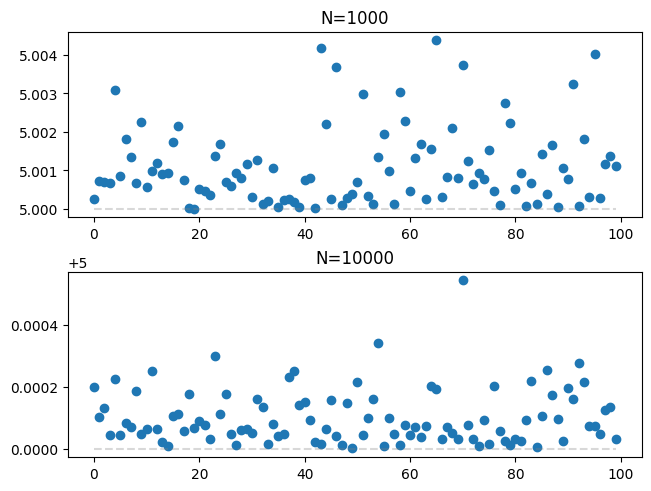

In [71]:
def y_gen(theta, n):
    return sp.stats.expon.rvs(size=n)+theta

def est_theta(tab): return min(tab)

fig, ax = plt.subplots(constrained_layout=True, nrows=2)

tab_y = y_gen(5,(100,1000))
tab_est= np.min(tab_y, axis=1)
ax[0].scatter(np.arange(len(tab_est)), tab_est)
ax[0].plot(np.arange(len(tab_est)), [5]*len(tab_est), linestyle='--', alpha=0.3, color='gray')
ax[0].set_title("N=1000")

tab_y = y_gen(5,(100,10000))
tab_est= np.min(tab_y, axis=1)
ax[1].scatter(np.arange(len(tab_est)), tab_est)
ax[1].plot(np.arange(len(tab_est)), [5]*len(tab_est), linestyle='--', alpha=0.3, color='gray')
ax[1].set_title("N=10000")

plt.show()

Zadanie 8

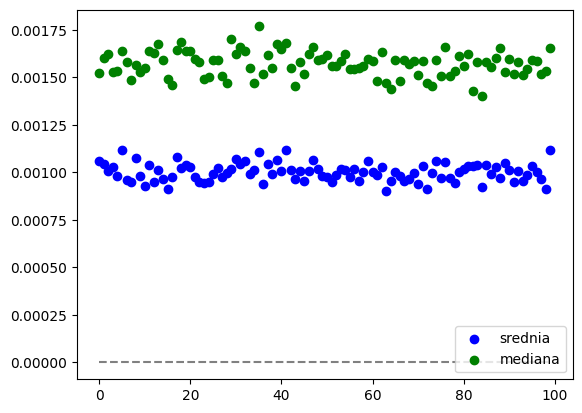

In [102]:
fig, ax = plt.subplots()
bledy1, bledy2 = [], []

for i in range(100):
    tab = sp.stats.norm.rvs(size=(1000, 1000))

    e1 = np.mean(tab, axis=1)
    e2 = np.median(tab, axis=1)

    bledy1.append(np.mean((e1)**2))
    bledy2.append(np.mean((e2)**2))


ax.scatter(np.arange(100), bledy1, color="blue", label="srednia")
ax.scatter(np.arange(100), bledy2, color="green", label="mediana")
ax.plot(np.arange(100), np.zeros(shape=100), linestyle='--', color='gray')
ax.legend(loc="lower right")
plt.show()

Zadanie 10

[]

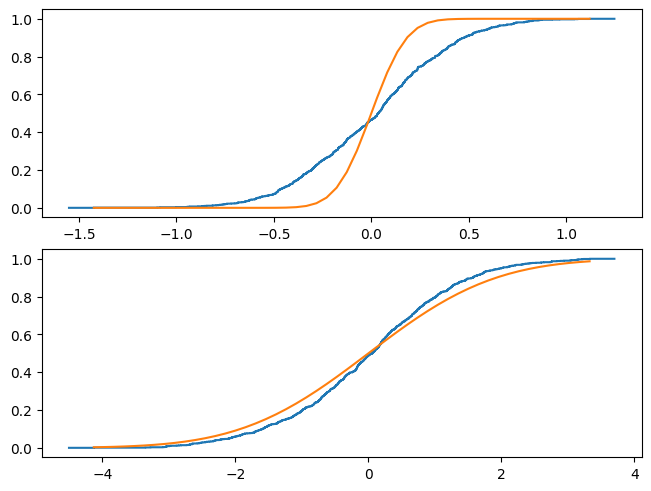

In [122]:
mu, s = 0, 1

def theta1(X):
    return sum(X)/7
def theta2(X):
    return (2*X[0]-X[6]+X[4])/2

tab_X = sp.stats.norm.rvs(mu, s, size=(1000,7))
tab_t1 = [theta1(X) for X in tab_X]
tab_t2 = [theta2(X) for X in tab_X]

fig, ax = plt.subplots(nrows=2, constrained_layout=True)
sp.stats.ecdf(tab_t1).cdf.plot(ax[0])
ax[0].plot(np.linspace(min(tab_t1), max(tab_t1)),
           sp.stats.norm.cdf(np.linspace(min(tab_t1), max(tab_t1)),mu,s/7))

sp.stats.ecdf(tab_t2).cdf.plot(ax[1])
ax[1].plot(np.linspace(min(tab_t2), max(tab_t2)),
           sp.stats.norm.cdf(np.linspace(min(tab_t2), max(tab_t2)),mu,3*s/2))

plt.plot()